In [297]:
import numpy as np # type: ignore
import cv2 # type: ignore
import matplotlib.pyplot as plt # type: ignore

Funciones para graficar imagenes una al lado de otra

In [298]:
def show_two_images(image1,image2, title1 = "", title2 ="", size =(8,5)):    
    # Crear una figura con dos subplots (una fila, dos columnas)
    fig, axes = plt.subplots(1, 2, figsize= size)  # Ajusta el tamaño de la figura según sea necesario

    # Mostrar la primera imagen en el primer subplot
    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')  # Opcional: para ocultar los ejes

    # Mostrar la segunda imagen en el segundo subplot
    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')  # Opcional: para ocultar los ejes

    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()



def show_three_images(image1,image2,image3, title1 = "", title2 ="", title3 ="", size = (8,5)):    
    # Crear una figura con dos subplots (una fila, dos columnas)
    fig, axes = plt.subplots(1, 3, figsize =size)  # Ajusta el tamaño de la figura según sea necesario

    # Mostrar la primera imagen en el primer subplot
    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')  # Opcional: para ocultar los ejes

    # Mostrar la segunda imagen en el segundo subplot
    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')  # Opcional: para ocultar los ejes

    # Mostrar la segunda imagen en el segundo subplot
    axes[2].imshow(image3, cmap='gray')
    axes[2].set_title(title3)
    axes[2].axis('off')  # Opcional: para ocultar los ejes
    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()

Cargo las imagenes y pruebo llevarlas a todas a una misma resolución

In [299]:
#Imagenes de 2500 pixeles (50x50)
pandaOriginal = cv2.imread("panda.bmp", cv2.IMREAD_GRAYSCALE)
vOriginal = cv2.imread("v.bmp", cv2.IMREAD_GRAYSCALE)
perroOriginal = cv2.imread("perro.bmp", cv2.IMREAD_GRAYSCALE)

#Imagenes de 2925 pixeles (65x45)
quijoteOriginal = cv2.imread("quijote.bmp", cv2.IMREAD_GRAYSCALE)
palomaOriginal = cv2.imread("paloma.bmp", cv2.IMREAD_GRAYSCALE)
toreroOriginal = cv2.imread("torero.bmp", cv2.IMREAD_GRAYSCALE)


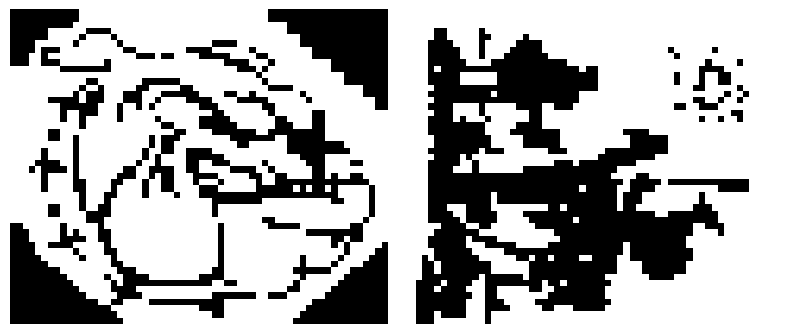

In [300]:
scale = (60,50)
pandaScaled = cv2.resize(pandaOriginal, scale, interpolation=cv2.INTER_NEAREST)
vScaled = cv2.resize(vOriginal, scale, interpolation=cv2.INTER_NEAREST)
perroScaled = cv2.resize(perroOriginal, scale, interpolation=cv2.INTER_NEAREST)
quijoteScaled = cv2.resize(quijoteOriginal, scale, interpolation=cv2.INTER_NEAREST)
palomaScaled = cv2.resize(palomaOriginal, scale, interpolation=cv2.INTER_NEAREST)
toreroScaled = cv2.resize(toreroOriginal, scale, interpolation=cv2.INTER_NEAREST)

show_two_images(perroScaled, quijoteScaled)


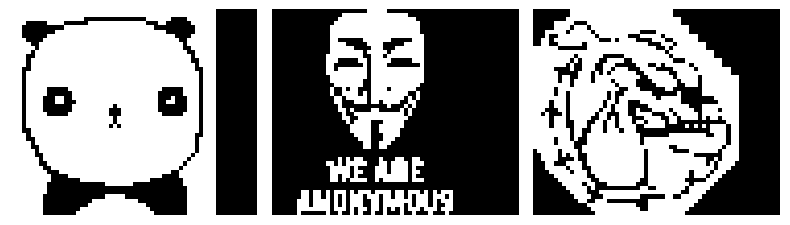

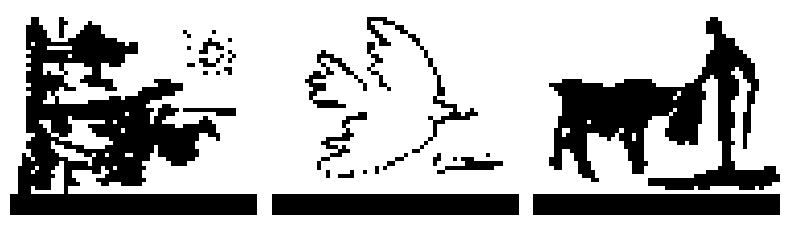

In [301]:
pandaFullfil = np.hstack([pandaOriginal.copy(),np.zeros((50, 10))])
vFullfil = np.hstack([vOriginal.copy(),np.zeros((50, 10))])
perroFullfil = np.hstack([perroOriginal.copy(),np.zeros((50, 10))])
quijoteFullfil = np.vstack([quijoteOriginal.copy(),np.zeros((5, 60))])
palomaFullfil = np.vstack([palomaOriginal.copy(),np.zeros((5, 60))])
toreroFullfil = np.vstack([toreroOriginal.copy(),np.zeros((5, 60))])

show_three_images(pandaFullfil,vFullfil,perroFullfil)
show_three_images(quijoteFullfil,palomaFullfil,toreroFullfil)


Para entrenar a la red neuronal o evaluarla, necesito a las imagenes en forma de vector y en el caso del entrenamiento cada imagen va a ser la columna de una matriz

In [302]:
def load_image_to_pattern(image):
    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY) # Convertir la imagen binaria a valores 0 y 1
    patron = (binary_image / 255.0) * 2 - 1 # Convertir la imagen binaria a valores -1 y 1
    return patron.flatten() # Me devuelve un arreglo unidimensional

In [303]:
def recover_image(imageVectorized, originalShape = scale):
    # Reconvertir el estado 1D a la forma original de la imagen
    recoveredImage = imageVectorized.reshape(originalShape)
    
    # Convertir de valores -1, 1 a 0, 255 para poder visualizar como imagen
    recoveredImage = (recoveredImage + 1) / 2 * 255
    return recoveredImage.astype(np.uint8)

Creo la clase de la Red Hopfield con todas las funciones para su entrenamiento y evaluacion

In [304]:
def sign_function(input):
    return np.where(input > 0,1,-1)


class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))


    def train(self, patterns):
        self.weights += patterns @ patterns.T
        np.fill_diagonal(self.weights, 0)

    def evaluate(self, inicialInput):
        state = inicialInput
        previousState= np.zeros((self.num_neurons, 1))
        cicles = 0
        while not (np.array_equal(state, previousState)):
            previousState = state
            indices = np.random.permutation(self.num_neurons)
            for i in indices :
                sum = np.dot(self.weights[i,:], state)
                state[i] = sign_function(sum)                
            cicles += 1 
        return state,cicles
    

Voy a probar una red entrenada solo con las imagenes 50x50

In [305]:
patterns1 = []
patterns1.append(load_image_to_pattern(pandaOriginal))
patterns1.append(load_image_to_pattern(vOriginal))
patterns1.append(load_image_to_pattern(perroOriginal))
patterns1 = np.array(patterns1).T

red1 = HopfieldNetwork(2500)
red1.train(patterns1)

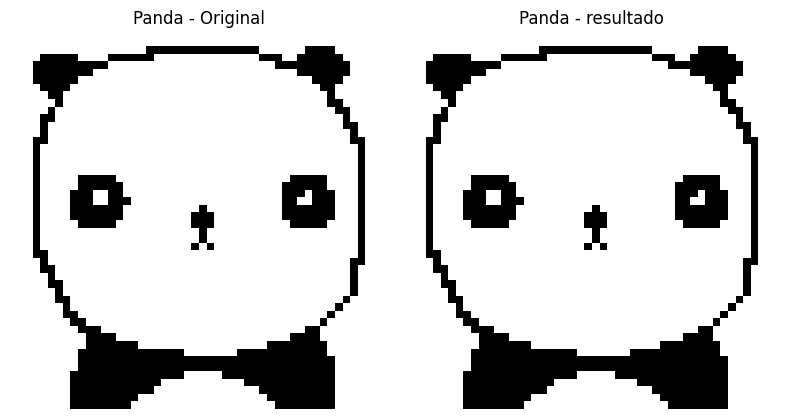

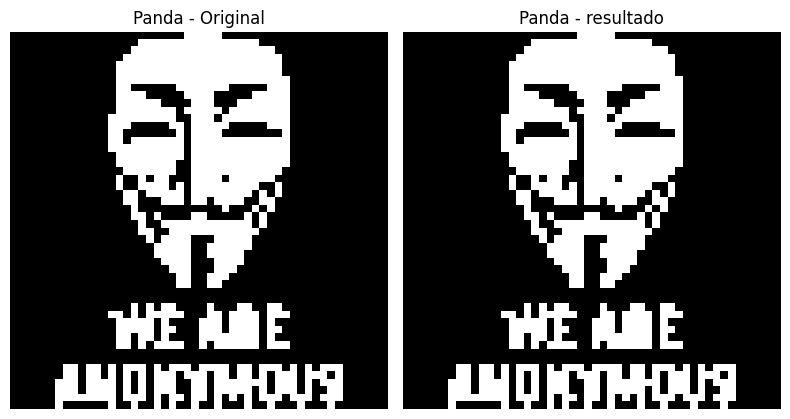

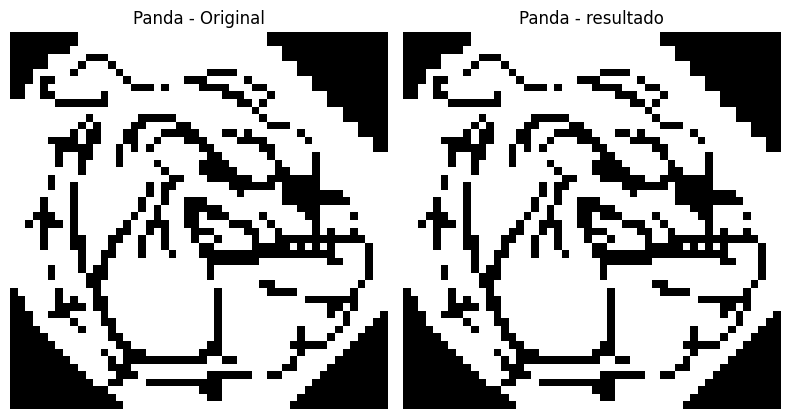

In [306]:
for i in [pandaOriginal, vOriginal, perroOriginal]:
    example,_ = red1.evaluate(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,50))
    show_two_images(i, Recovered, "Panda - Original", "Panda - resultado")

1


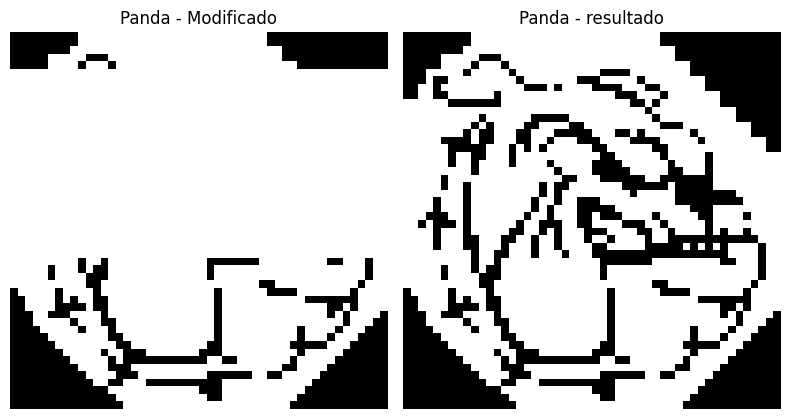

In [307]:
pandaRecortado = perroOriginal.copy()
pandaRecortado[5:30,:] = 255
example,cicles = red1.evaluate(load_image_to_pattern(pandaRecortado))
Recovered = recover_image(example, (50,50))
print(cicles)
show_two_images(pandaRecortado, Recovered, "Panda - Modificado", "Panda - resultado")

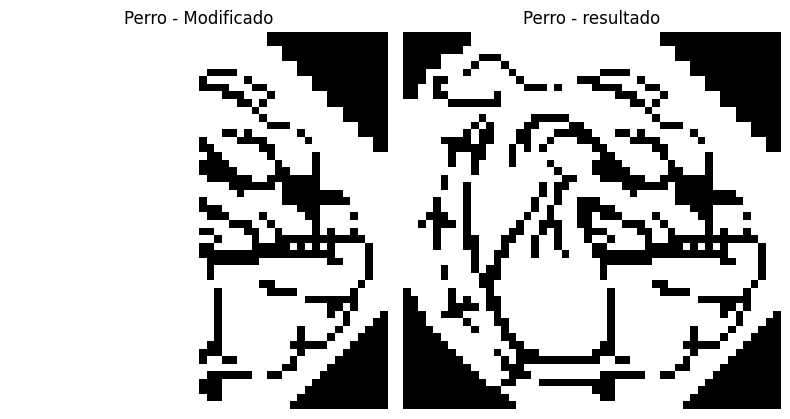

In [308]:
perroRecortado = perroOriginal.copy()
perroRecortado[:,0:25] = 255
example,_ = red1.evaluate(load_image_to_pattern(perroRecortado))
Recovered = recover_image(example, (50,50))
show_two_images(perroRecortado, Recovered, "Perro - Modificado", "Perro - resultado")


Pruebo red neuronal para el caso de completar los pixeles faltantes de las imagenes

In [309]:
patterns2 = []
patterns2.append(load_image_to_pattern(pandaFullfil))
patterns2.append(load_image_to_pattern(vFullfil))
patterns2.append(load_image_to_pattern(perroFullfil))
patterns2.append(load_image_to_pattern(palomaFullfil))
patterns2.append(load_image_to_pattern(toreroFullfil))
patterns2.append(load_image_to_pattern(quijoteFullfil))
patterns2 = np.array(patterns2).T

red2 = HopfieldNetwork(3000)
red2.train(patterns2)

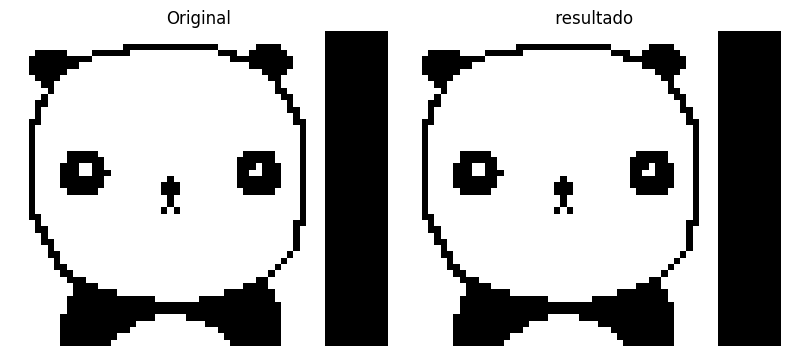

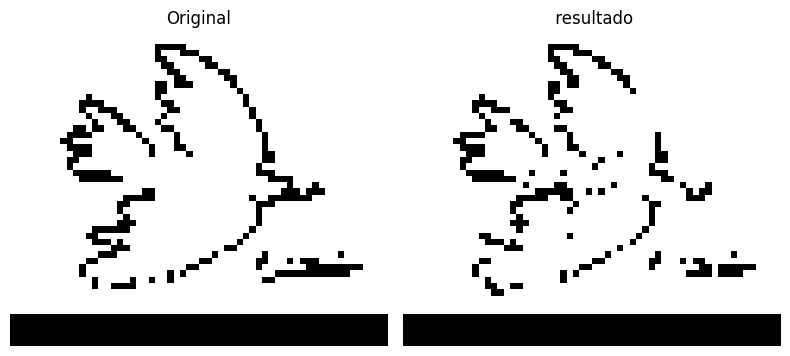

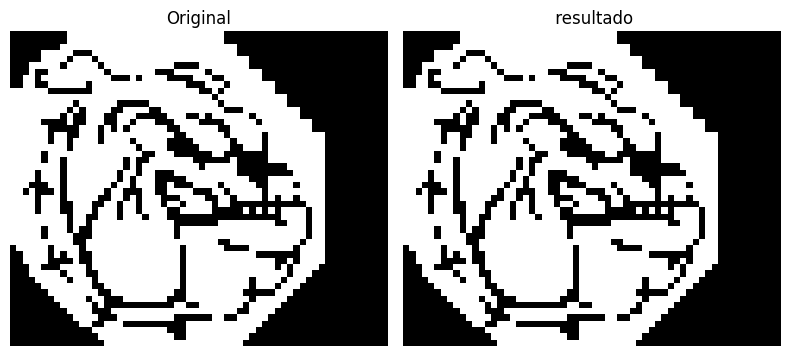

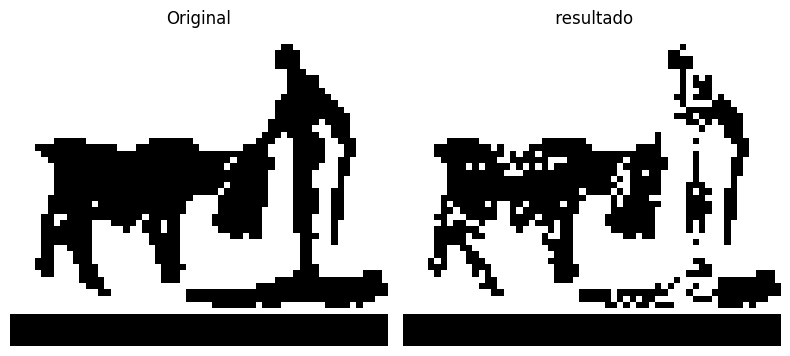

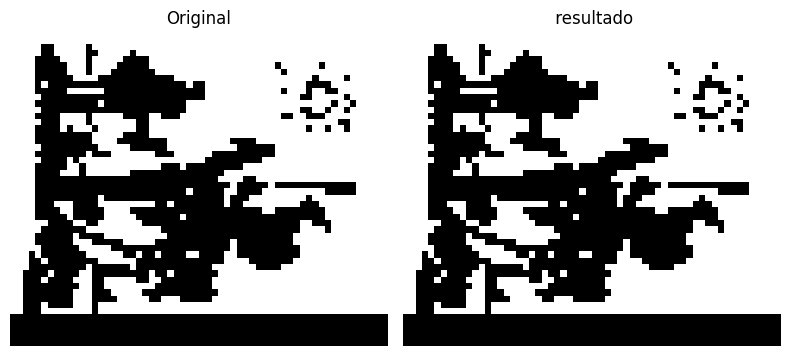

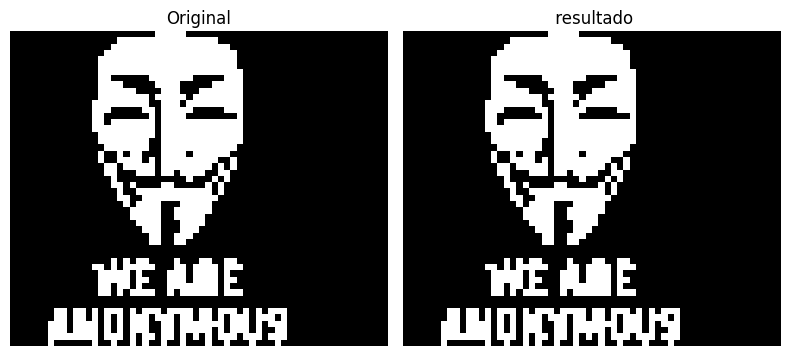

In [310]:
for i in [pandaFullfil, palomaFullfil, perroFullfil, toreroFullfil, quijoteFullfil, vFullfil]:
    example,_ = red2.evaluate(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,60))
    show_two_images(i, Recovered, "Original", " resultado")

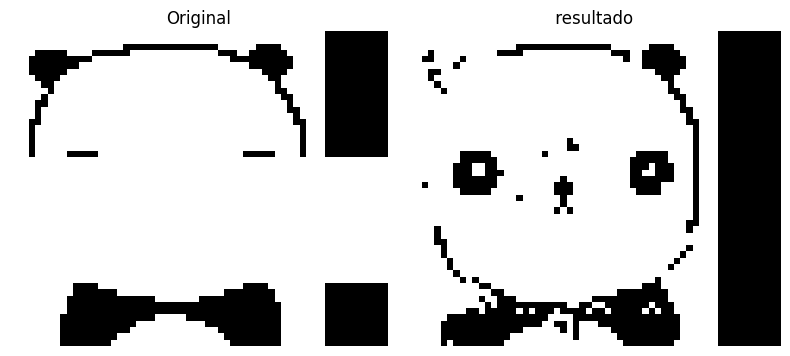

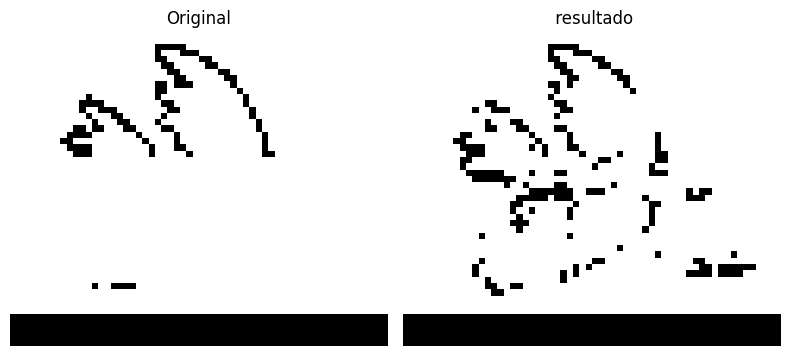

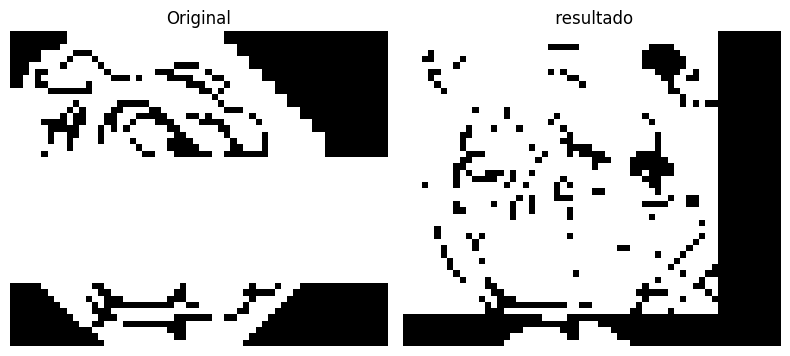

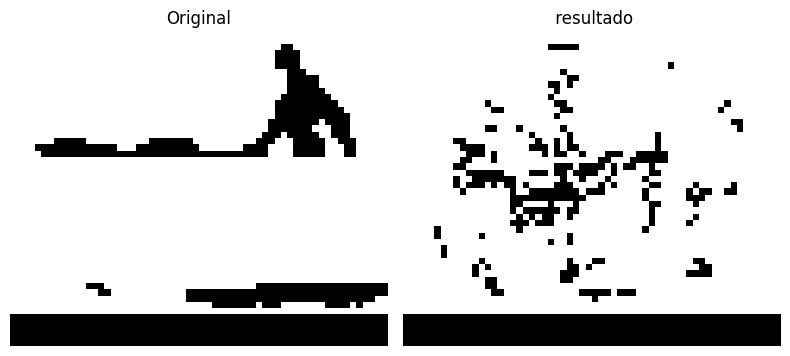

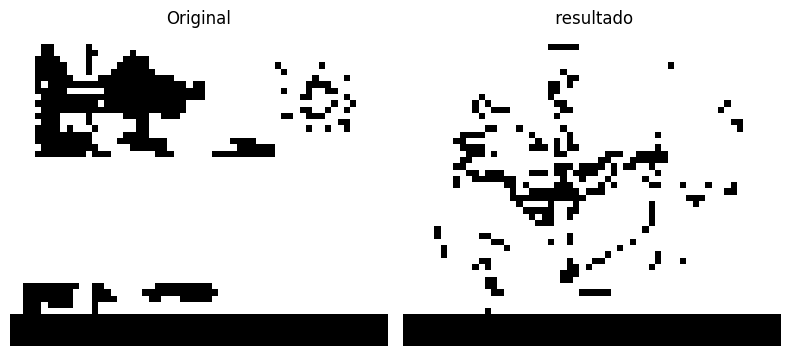

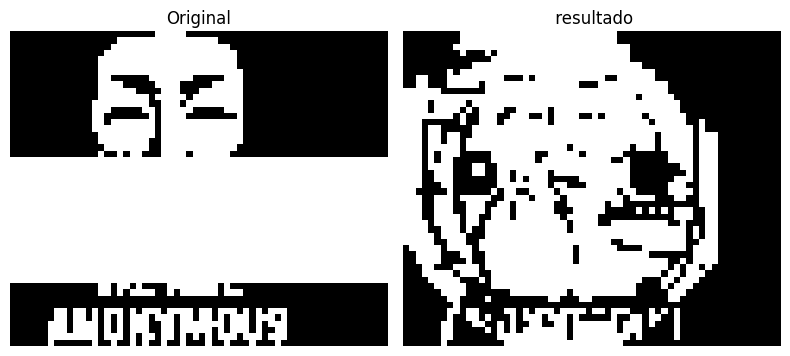

In [311]:
for i in [pandaFullfil, palomaFullfil, perroFullfil, toreroFullfil, quijoteFullfil, vFullfil]:
    aux = i.copy()
    aux[20:40, :] = 255
    example,_ = red2.evaluate(load_image_to_pattern(aux))
    Recovered = recover_image(example, (50,60))
    show_two_images(aux, Recovered, "Original", " resultado")

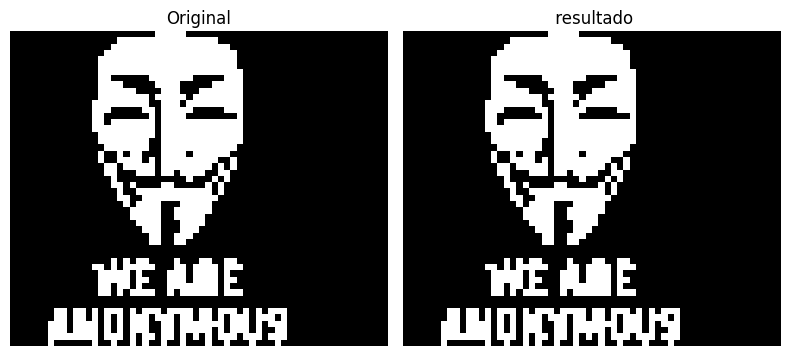

In [312]:
example,_ = red2.evaluate(load_image_to_pattern(vFullfil))
Recovered = recover_image(example, (50,60))
show_two_images(vFullfil, Recovered, "Original", " resultado")

Ahora pruebo una red neuronal con imagenes escaladas

In [313]:
patterns3 = []
patterns3.append(load_image_to_pattern(pandaScaled))
patterns3.append(load_image_to_pattern(vScaled))
patterns3.append(load_image_to_pattern(perroScaled))
patterns3.append(load_image_to_pattern(palomaScaled))
patterns3.append(load_image_to_pattern(toreroScaled))
patterns3.append(load_image_to_pattern(quijoteScaled))
patterns3 = np.array(patterns3).T

red3 = HopfieldNetwork(3000)
red3.train(patterns3)

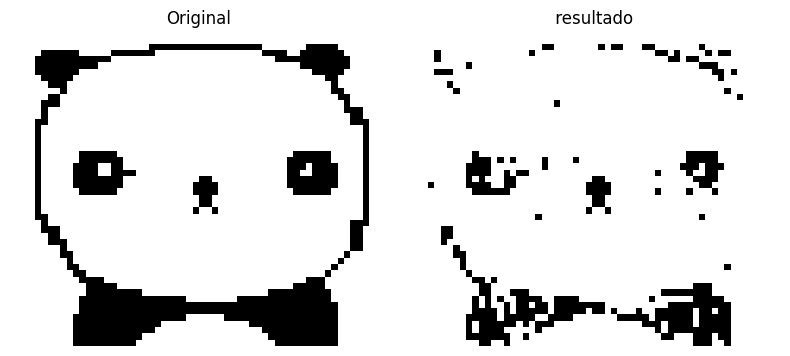

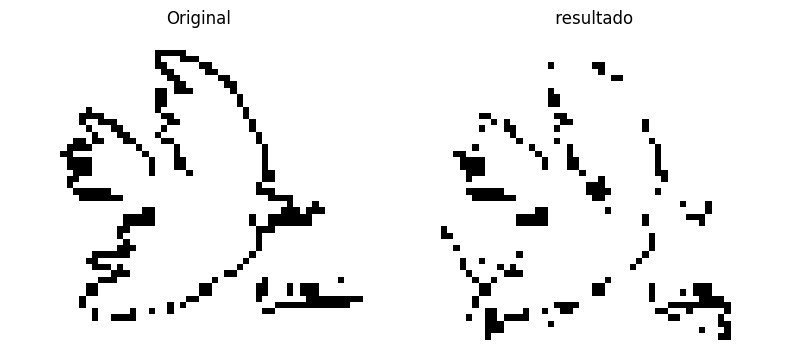

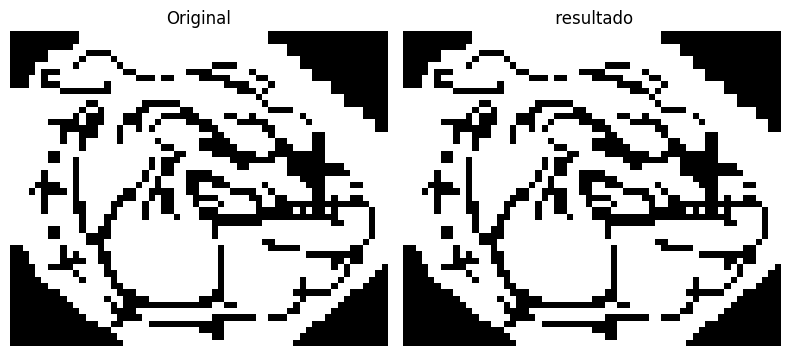

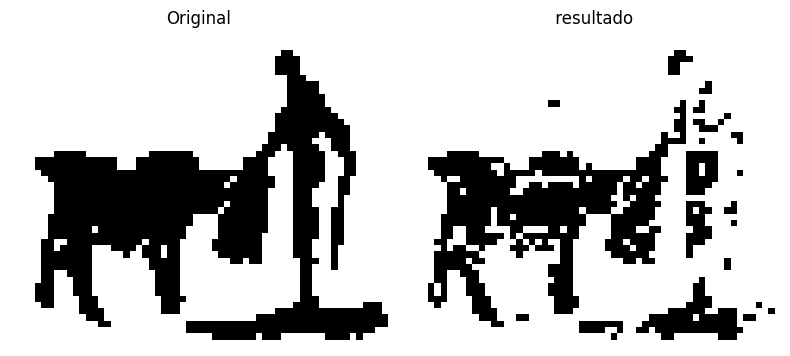

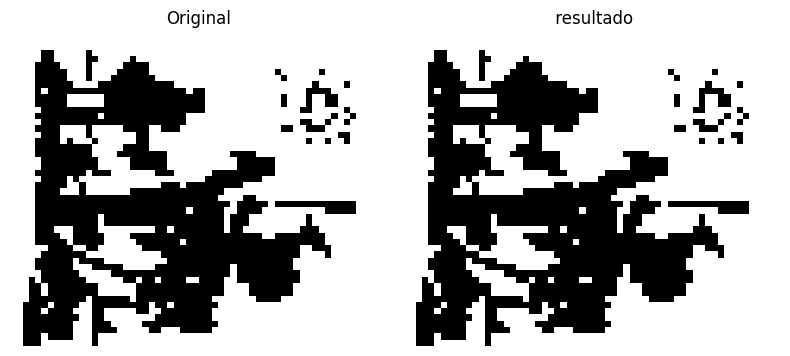

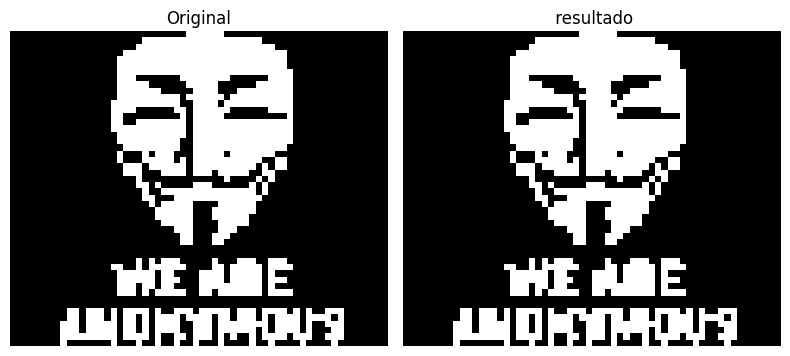

In [314]:
for i in [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]:
    example,_ = red3.evaluate(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,60))
    show_two_images(i, Recovered, "Original", " resultado")

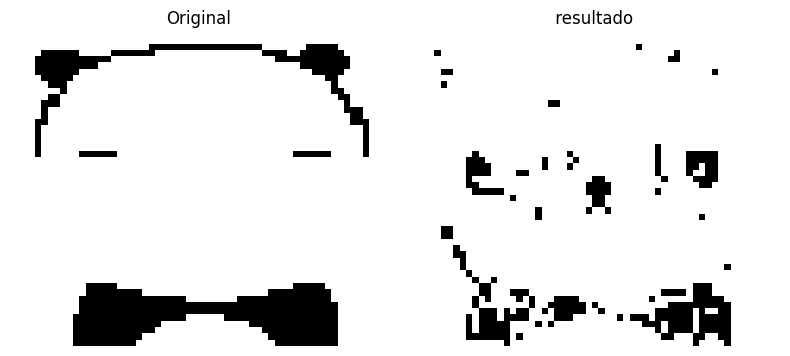

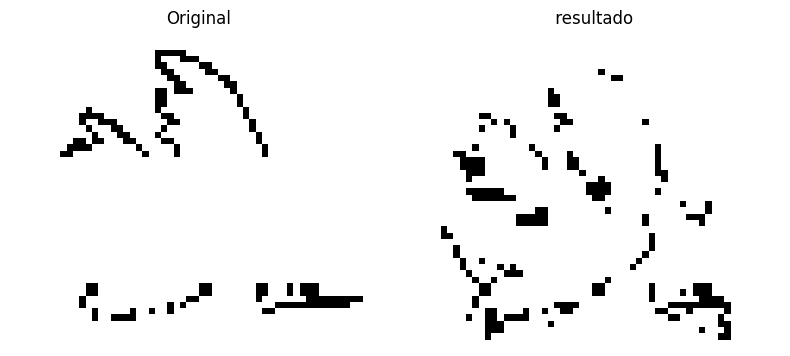

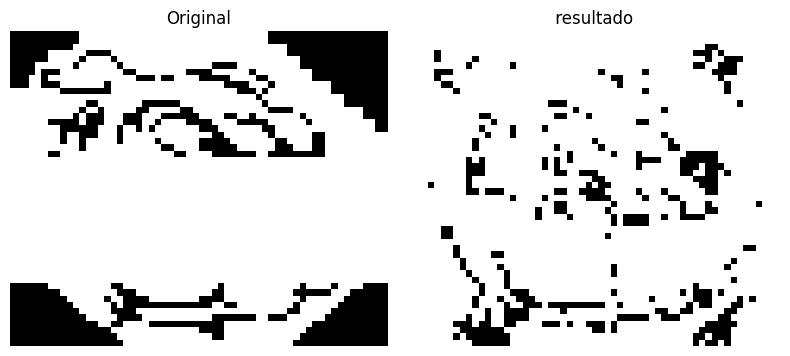

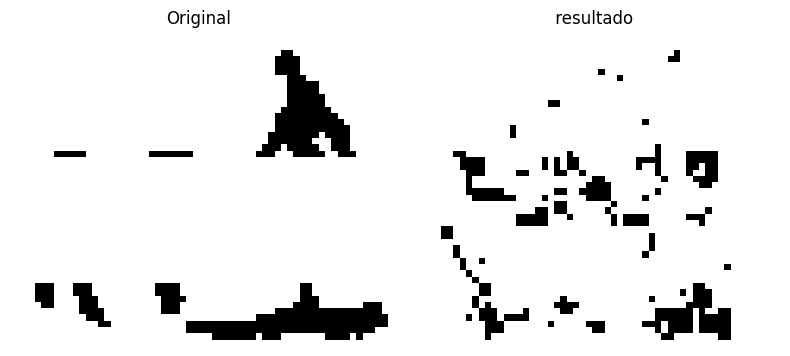

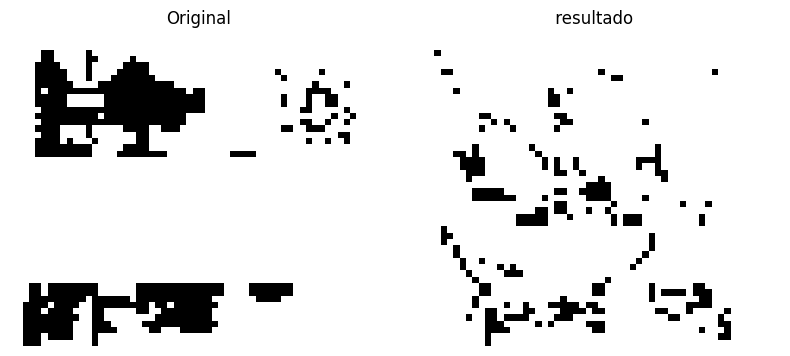

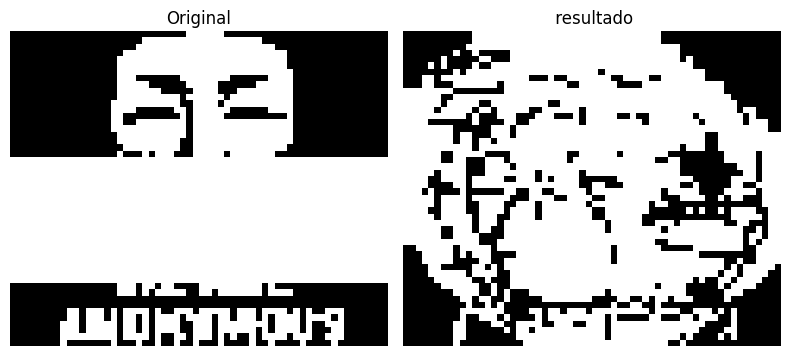

In [315]:
for i in [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]:
    aux = i.copy()
    aux[20:40, :] = 255
    example,_ = red3.evaluate(load_image_to_pattern(aux))
    Recovered = recover_image(example, (50,60))
    show_two_images(aux, Recovered, "Original", " resultado")